# Quickstart: Estructuras de Datos y Lógica en Python

**Workshop hands-on** — aprendemos Python con un ejemplo musical: el **mástil de guitarra** en afinación estándar **EADGBE**.

> **¿Poca experiencia con Python?** Empieza por [`quickstart_structures_logic.ipynb`](quickstart_structures_logic.ipynb) (Módulo 1: listas y diccionarios con acordes). Luego continúa aquí.

### Objetivos

| Módulo | Qué aprenderás |
|--------|----------------|
| **Estructuras de Datos** | Listas y diccionarios para modelar notas y acordes |
| **Iteraciones** | Bucles `for` para recorrer el mástil y buscar notas |
| **Funciones** | Bloques reutilizables para dibujar y resaltar acordes |
| **Hands-on** | Visualizar acordes pintando círculos de distinto color en el mástil |

### Entorno local con uv

```bash
uv sync
uv run jupyter lab   # abre este notebook en el navegador
```

En **Cursor / VS Code**, selecciona el kernel `.venv/bin/python`.

**Google Colab:** sube el `.ipynb` y la carpeta `src/` — no requiere uv.

In [ ]:
# Colab ya incluye matplotlib; en entorno local: pip install matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from IPython.display import display, Image

print("Entorno listo.")

Entorno listo.


## Referencia visual

El mástil tiene **6 cuerdas** (e, B, G, D, A, E — de aguda a grave) y **13 columnas** (cuerda al aire + trastes 1–12). Cada intersección contiene una nota musical.

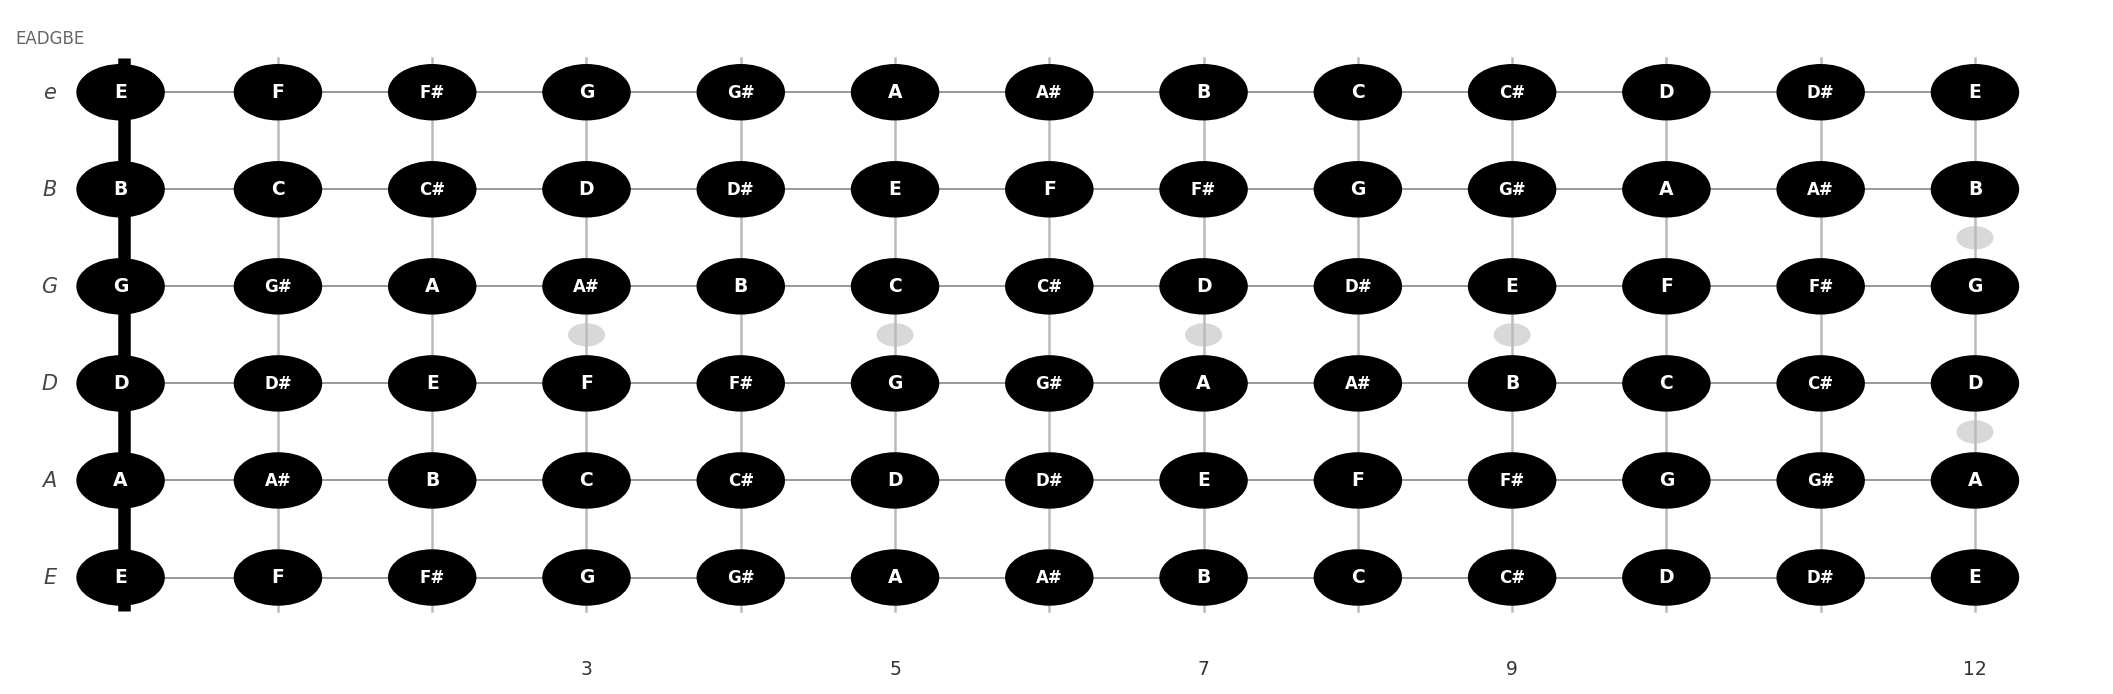

In [ ]:
from pathlib import Path

ruta_imagen = Path("src/image.png")
if ruta_imagen.exists():
    display(Image(filename=str(ruta_imagen), width=900))
else:
    print("Sube src/image.png al entorno o clona el repositorio.")
    print("No te preocupes: en las siguientes celdas generamos el mástil con código.")

## 1. Listas — el mástil como matriz de notas

Cada **cuerda** es una **lista** de notas. El índice `0` es la cuerda al aire; el índice `3` es el traste 3.

El mástil completo es una **lista de listas** (6 filas × 13 columnas).

In [ ]:
CHROMATIC = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]

# Afinación EADGBE — de la cuerda 1 (Mi agudo) a la 6 (Mi grave)
CUERDAS_ABIERTAS = ["E", "B", "G", "D", "A", "E"]
ETIQUETAS_CUERDAS = ["e", "B", "G", "D", "A", "E"]
NUM_TRASTES = 12


def nota_en_traste(nota_abierta: str, traste: int) -> str:
    """Calcula la nota en un traste dado a partir de la cuerda al aire."""
    idx = (CHROMATIC.index(nota_abierta) + traste) % 12
    return CHROMATIC[idx]


def construir_mastil() -> list[list[str]]:
    """Devuelve el mástil: mastil[cuerda][traste] → nota."""
    return [
        [nota_en_traste(abierta, t) for t in range(NUM_TRASTES + 1)]
        for abierta in CUERDAS_ABIERTAS
    ]


mastil = construir_mastil()

# Indexación: cuerda 5 (La), traste 3 → índices [4][3]
print("Cuerda La (5), traste 3:", mastil[4][3])
print("Cuerda Re (4), traste 2:", mastil[3][2])
print("Cuerda Si (2), traste 1:", mastil[1][1])

Cuerda La (5), traste 3: C
Cuerda Re (4), traste 2: E
Cuerda Si (2), traste 1: C


## 2. Iteraciones — buscar notas en el mástil

Con un bucle `for` anidado recorremos todas las posiciones y encontramos dónde aparece una nota (por ejemplo, todas las **C**).

In [ ]:
def buscar_nota(mastil: list[list[str]], nota: str) -> list[tuple[int, int]]:
    """Devuelve [(cuerda, traste), ...] donde aparece la nota (1-indexed)."""
    posiciones = []
    for i, fila in enumerate(mastil):
        for j, n in enumerate(fila):
            if n == nota:
                posiciones.append((i + 1, j))  # cuerda 1..6, traste 0..12
    return posiciones


todas_las_c = buscar_nota(mastil, "C")
print(f"La nota 'C' aparece {len(todas_las_c)} veces en el mástil:")
for cuerda, traste in todas_las_c:
    print(f"  Cuerda {cuerda} ({ETIQUETAS_CUERDAS[cuerda - 1]}), traste {traste}")

La nota 'C' aparece 6 veces en el mástil:
  Cuerda 1 (e), traste 8
  Cuerda 2 (B), traste 1
  Cuerda 3 (G), traste 5
  Cuerda 4 (D), traste 10
  Cuerda 5 (A), traste 3
  Cuerda 6 (E), traste 8


## 3. Diccionarios — acordes como objetos

Un **acorde** se modela con un diccionario: nombre, notas teóricas y **digitación** (qué cuerda/traste pulsar).

**Do Mayor (C)** en posición abierta — digitación `x-3-2-0-1-0`:

| Cuerda | Traste | Nota |
|--------|--------|------|
| 2 (Si) | 1 | C |
| 4 (Re) | 2 | E |
| 5 (La) | 3 | C |

In [ ]:
acorde_do_mayor = {
    "nombre": "C",
    "nombre_completo": "Do Mayor",
    "notas_teoricas": ["C", "E", "G"],
    "posiciones": [
        {"cuerda": 2, "traste": 1, "nota": "C"},
        {"cuerda": 4, "traste": 2, "nota": "E"},
        {"cuerda": 5, "traste": 3, "nota": "C"},
    ],
    "color_resaltado": "#E53935",
}

# Diccionario de acordes — clave → acorde
acordes = {
    "C": acorde_do_mayor,
    "Am": {
        "nombre": "Am",
        "nombre_completo": "La menor",
        "notas_teoricas": ["A", "C", "E"],
        "posiciones": [
            {"cuerda": 2, "traste": 1, "nota": "C"},
            {"cuerda": 3, "traste": 2, "nota": "A"},
            {"cuerda": 4, "traste": 2, "nota": "E"},
        ],
        "color_resaltado": "#1E88E5",
    },
    "G": {
        "nombre": "G",
        "nombre_completo": "Sol Mayor",
        "notas_teoricas": ["G", "B", "D"],
        "posiciones": [
            {"cuerda": 1, "traste": 3, "nota": "G"},
            {"cuerda": 5, "traste": 2, "nota": "B"},
            {"cuerda": 6, "traste": 3, "nota": "G"},
        ],
        "color_resaltado": "#43A047",
    },
}

# Validar: la nota en el mástil coincide con la digitación
for pos in acorde_do_mayor["posiciones"]:
    c, t, esperada = pos["cuerda"], pos["traste"], pos["nota"]
    real = mastil[c - 1][t]
    ok = "OK" if real == esperada else "ERROR"
    print(f"[{ok}] Cuerda {c}, traste {t}: esperada={esperada}, real={real}")

[OK] Cuerda 2, traste 1: esperada=C, real=C
[OK] Cuerda 4, traste 2: esperada=E, real=E
[OK] Cuerda 5, traste 3: esperada=C, real=C


## 4. Funciones — dibujar y resaltar acordes

Separamos responsabilidades en funciones reutilizables:

1. `obtener_color()` — decide si una posición pertenece al acorde.
2. `dibujar_mastil()` — genera la imagen completa con círculos de color configurable.

In [ ]:
MARCADORES_TRASTE = {3, 5, 7, 9, 12}


def obtener_color(
    cuerda: int,
    traste: int,
    acorde: dict | None,
    color_default: str = "black",
) -> str:
    if acorde is None:
        return color_default
    for pos in acorde["posiciones"]:
        if pos["cuerda"] == cuerda and pos["traste"] == traste:
            return acorde.get("color_resaltado", "red")
    return color_default


def dibujar_mastil(
    mastil: list[list[str]],
    acorde: dict | None = None,
    titulo: str = "Mástil EADGBE",
) -> None:
    num_cuerdas = len(mastil)
    num_trastes = len(mastil[0]) - 1

    fig, ax = plt.subplots(figsize=(14, 4.5), facecolor="white")
    ax.set_facecolor("white")
    ax.set_xlim(-0.6, num_trastes + 0.8)
    ax.set_ylim(-0.8, num_cuerdas - 0.2)
    ax.invert_yaxis()
    ax.axis("off")
    ax.set_title(titulo, fontsize=14, pad=12)

    for s in range(num_cuerdas):
        ax.plot([0, num_trastes], [s, s], color="#888888", linewidth=0.8, zorder=1)

    ax.plot([0, 0], [-0.35, num_cuerdas - 0.65], color="black", linewidth=6, zorder=2)

    for f in range(1, num_trastes + 1):
        ax.plot([f, f], [-0.35, num_cuerdas - 0.65], color="#BBBBBB", linewidth=1.2, zorder=2)

    for f in MARCADORES_TRASTE:
        if f == 12:
            for s in (1.5, 3.5):
                ax.add_patch(Circle((f, s), 0.12, facecolor="#D8D8D8", edgecolor="none", zorder=0))
        else:
            ax.add_patch(Circle((f, 2.5), 0.12, facecolor="#D8D8D8", edgecolor="none", zorder=0))

    for s, fila in enumerate(mastil):
        for t, nota in enumerate(fila):
            x = t if t > 0 else -0.02
            cuerda = s + 1
            color = obtener_color(cuerda, t, acorde)
            ax.add_patch(Circle((x, s), 0.28, facecolor=color, edgecolor=color, zorder=3))
            ax.text(
                x, s, nota,
                ha="center", va="center", color="white",
                fontsize=9 if len(nota) <= 1 else 8, fontweight="bold", zorder=4,
            )

    for f in MARCADORES_TRASTE:
        ax.text(f, num_cuerdas - 0.15, str(f), ha="center", va="top", fontsize=9, color="#333333")

    for s, etiqueta in enumerate(ETIQUETAS_CUERDAS):
        ax.text(-0.48, s, etiqueta, ha="center", va="center", fontsize=10, color="#444444", fontstyle="italic")

    ax.text(-0.48, -0.55, "EADGBE", ha="center", va="center", fontsize=8, color="#666666")

    plt.tight_layout()
    plt.show()

## 5. Hands-on — pintar Do Mayor (C)

Las notas del acorde se resaltan en **rojo**. El resto permanece en negro.

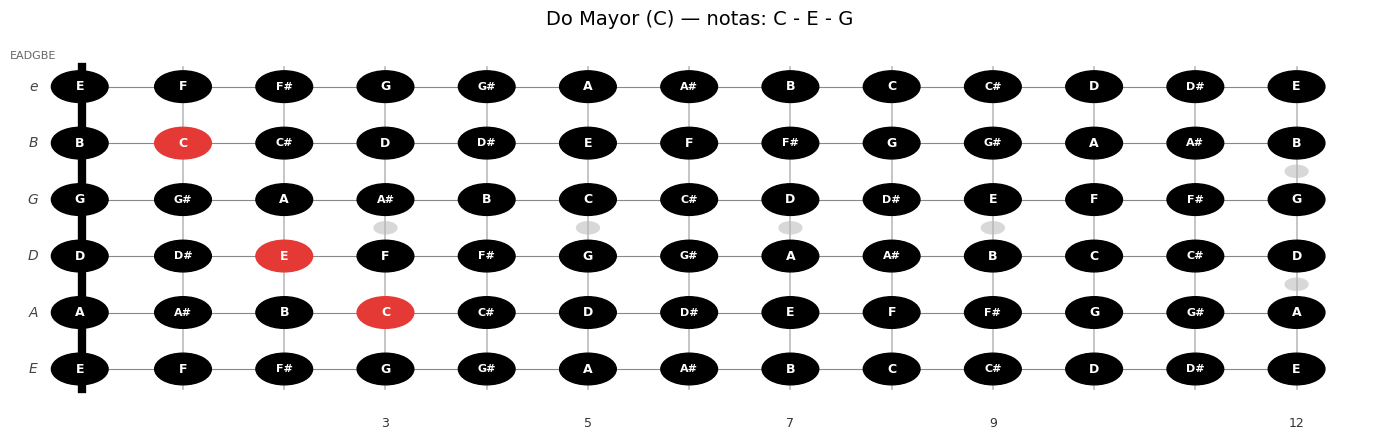

In [ ]:
dibujar_mastil(
    mastil,
    acorde=acordes["C"],
    titulo=f"{acordes['C']['nombre_completo']} ({acordes['C']['nombre']}) — notas: {' - '.join(acordes['C']['notas_teoricas'])}",
)

## 6. Iteraciones — recorrer un diccionario de acordes

Con un bucle `for` sobre `acordes.items()` dibujamos cada acorde con su color.


--- Do Mayor (C) ---
  Cuerda 2, traste 1 → C
  Cuerda 4, traste 2 → E
  Cuerda 5, traste 3 → C


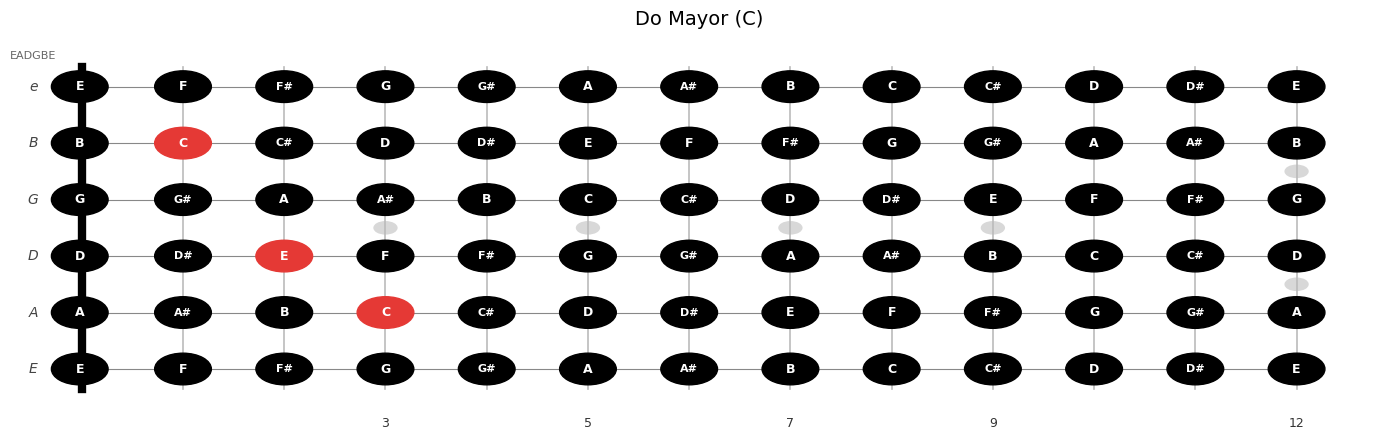


--- La menor (Am) ---
  Cuerda 2, traste 1 → C
  Cuerda 3, traste 2 → A
  Cuerda 4, traste 2 → E


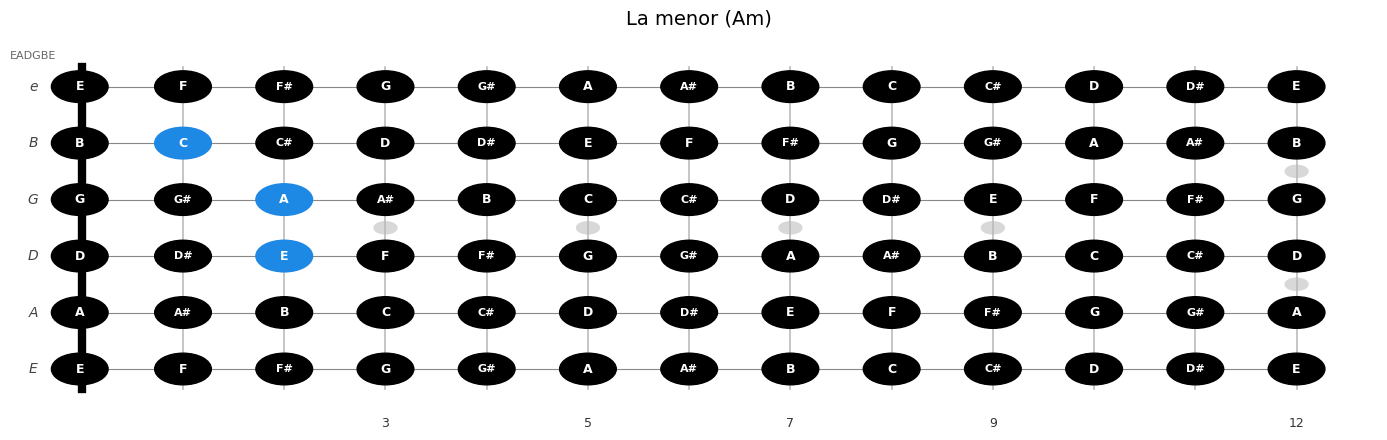


--- Sol Mayor (G) ---
  Cuerda 1, traste 3 → G
  Cuerda 5, traste 2 → B
  Cuerda 6, traste 3 → G


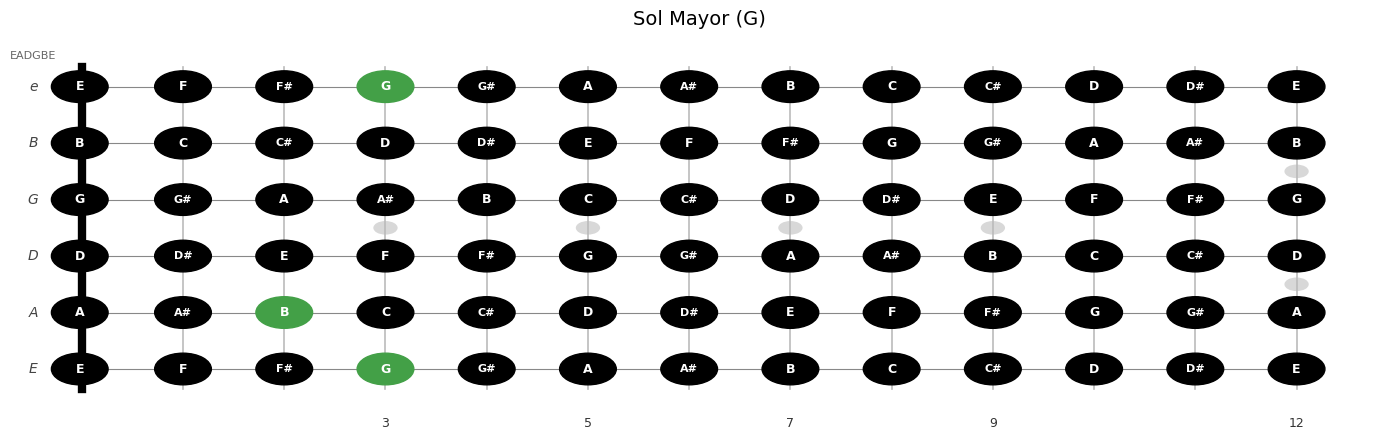

In [ ]:
for clave, acorde in acordes.items():
    print(f"\n--- {acorde['nombre_completo']} ({clave}) ---")
    for pos in acorde["posiciones"]:
        print(f"  Cuerda {pos['cuerda']}, traste {pos['traste']} → {pos['nota']}")
    dibujar_mastil(
        mastil,
        acorde=acorde,
        titulo=f"{acorde['nombre_completo']} ({acorde['nombre']})",
    )

## 7. Ejercicio — crea tu propio acorde

Define un acorde nuevo en el diccionario `acordes` (por ejemplo **Em** o **D**) y dibújalo cambiando `color_resaltado`.

Pista para **Em** (`022000`): cuerda 5 traste 2 → B, cuerda 4 traste 2 → E, cuerda 2 traste 0 → B.

In [ ]:
# Tu turno: descomenta y completa
# acordes["Em"] = {
#     "nombre": "Em",
#     "nombre_completo": "Mi menor",
#     "notas_teoricas": ["E", "G", "B"],
#     "posiciones": [
#         {"cuerda": 2, "traste": 0, "nota": "B"},
#         {"cuerda": 4, "traste": 2, "nota": "E"},
#         {"cuerda": 5, "traste": 2, "nota": "B"},
#     ],
#     "color_resaltado": "#8E24AA",
# }
# dibujar_mastil(mastil, acorde=acordes["Em"], titulo="Mi menor (Em)")

## Resumen

| Concepto | Aplicación en el mástil |
|----------|-------------------------|
| **Lista** | Cada cuerda = `[nota₀, nota₁, …, nota₁₂]` |
| **Lista de listas** | `mastil[cuerda][traste]` → nota |
| **Diccionario** | Acorde con `nombre`, `notas_teoricas`, `posiciones`, `color_resaltado` |
| **Bucle `for`** | Buscar notas / recorrer acordes |
| **Función** | `dibujar_mastil()` reutilizable con cualquier acorde |

---

**Siguiente paso:** añade acordes con cejilla, o exporta la imagen con `fig.savefig('acorde_C.png')`.

**Bonus opcional:** [`funciones_y_diseno.ipynb`](funciones_y_diseno.ipynb) — por qué separamos `obtener_color()` y `dibujar_mastil()` (SRP y OCP).